# Task 4

## Answer 4.a

First, import the required Python packages.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

Define the relevant constants.

In [2]:
rolling_window = 21

c = 0.99
inverse_cdf = norm.ppf(1-c)
factor = inverse_cdf
print(f'Exact value of Normal ICDF for p = {1-c:.2f} is: {inverse_cdf}')

Exact value of Normal ICDF for p = 0.01 is: -2.3263478740408408


Load the index data from the Excel file.

In [3]:
data = pd.read_excel('Indices_Download_2026.xlsx', index_col='Date')
data.index = pd.to_datetime(data.index)
data

,^GSPC,^NDX
Date,,
2015-10-15,2023.859985,4418.220215
2015-10-16,2033.109985,4438.620117
2015-10-19,2033.660034,4462.069824
2015-10-20,2030.770020,4438.180176
2015-10-21,2018.939941,4413.520020
...,...,...
2026-01-26,6950.229980,25713.210938
2026-01-27,6978.600098,25939.740234
2026-01-28,6978.029785,26022.789062


Compute the 1D log-return.

In [4]:
data['LogReturn'] = np.log(data['^GSPC']) - np.log(data['^GSPC'].shift(1))
data

,^GSPC,^NDX,LogReturn
Date,,,
2015-10-15,2023.859985,4418.220215,NaN
2015-10-16,2033.109985,4438.620117,0.004560
2015-10-19,2033.660034,4462.069824,0.000271
2015-10-20,2030.770020,4438.180176,-0.001422
2015-10-21,2018.939941,4413.520020,-0.005842
...,...,...,...
2026-01-26,6950.229980,25713.210938,0.004994
2026-01-27,6978.600098,25939.740234,0.004074
2026-01-28,6978.029785,26022.789062,-0.000082


Compute the realised forward 10-day log return.

In [5]:
data['Forward10dReturn'] = np.log(data['^GSPC'].shift(-10) / data['^GSPC'])
data

,^GSPC,^NDX,LogReturn,Forward10dReturn
Date,,,,
2015-10-15,2023.859985,4418.220215,NaN,0.031875
2015-10-16,2033.109985,4438.620117,0.004560,0.022494
2015-10-19,2033.660034,4462.069824,0.000271,0.034027
2015-10-20,2030.770020,4438.180176,-0.001422,0.038173
2015-10-21,2018.939941,4413.520020,-0.005842,0.040464
...,...,...,...,...
2026-01-26,6950.229980,25713.210938,0.004994,NaN
2026-01-27,6978.600098,25939.740234,0.004074,NaN
2026-01-28,6978.029785,26022.789062,-0.000082,NaN


Restrict the sample to the period from 2025-01-01 to 2026-01-15. 

In [6]:
data = data.loc['2025-01-01':'2026-01-15'].copy()
data

,^GSPC,^NDX,LogReturn,Forward10dReturn
Date,,,,
2025-01-02,5868.549805,20975.619141,-0.002226,0.021595
2025-01-03,5942.470215,21326.160156,0.012517,0.017808
2025-01-06,5975.379883,21559.500000,0.005523,0.018404
2025-01-07,5909.029785,21173.039062,-0.011166,0.034870
2025-01-08,5918.250000,21180.970703,0.001559,0.030451
...,...,...,...,...
2026-01-09,6966.279785,25766.259766,0.006455,-0.002307
2026-01-12,6977.270020,25787.660156,0.001576,0.000191
2026-01-13,6963.740234,25741.949219,-0.001941,0.002050


To initialise the EWMA recursion, use the average squared daily log return over this same sample period.

Compute the initial variance as the average of squared daily log returns over the selected backtesting sample.

In [7]:
initial_variance = (data['LogReturn'].dropna() ** 2).mean()
print(f'Initial variance from the backtesting sample squared returns: {initial_variance:.6f}')

Initial variance from the backtesting sample squared returns: 0.000133


Use this sample average as the first EWMA variance estimate, and then update the remaining observations recursively.

With decay parameter $\lambda = 0.72$, the recursion is
$$\sigma_{t+1|t}^2 = \lambda\sigma_{t|t-1}^2 + (1-\lambda)r_t^2$$

In [8]:
param = 0.72

data.loc[data.index[0], 'variance'] = initial_variance

for i in range(1, len(data)):
    variance = param * data.loc[data.index[i - 1], 'variance'] + (1 - param) * data.loc[data.index[i - 1], 'LogReturn']**2
    data.loc[data.index[i], 'variance'] = variance

data

,^GSPC,^NDX,LogReturn,Forward10dReturn,variance
Date,,,,,
2025-01-02,5868.549805,20975.619141,-0.002226,0.021595,0.000133
2025-01-03,5942.470215,21326.160156,0.012517,0.017808,0.000097
2025-01-06,5975.379883,21559.500000,0.005523,0.018404,0.000114
2025-01-07,5909.029785,21173.039062,-0.011166,0.034870,0.000091
2025-01-08,5918.250000,21180.970703,0.001559,0.030451,0.000100
...,...,...,...,...,...
2026-01-09,6966.279785,25766.259766,0.006455,-0.002307,0.000018
2026-01-12,6977.270020,25787.660156,0.001576,0.000191,0.000024
2026-01-13,6963.740234,25741.949219,-0.001941,0.002050,0.000018


In [9]:
data['SD'] = np.sqrt(data['variance'])
data

,^GSPC,^NDX,LogReturn,Forward10dReturn,variance,SD
Date,,,,,,
2025-01-02,5868.549805,20975.619141,-0.002226,0.021595,0.000133,0.011540
2025-01-03,5942.470215,21326.160156,0.012517,0.017808,0.000097,0.009863
2025-01-06,5975.379883,21559.500000,0.005523,0.018404,0.000114,0.010673
2025-01-07,5909.029785,21173.039062,-0.011166,0.034870,0.000091,0.009516
2025-01-08,5918.250000,21180.970703,0.001559,0.030451,0.000100,0.010006
...,...,...,...,...,...,...
2026-01-09,6966.279785,25766.259766,0.006455,-0.002307,0.000018,0.004205
2026-01-12,6977.270020,25787.660156,0.001576,0.000191,0.000024,0.004939
2026-01-13,6963.740234,25741.949219,-0.001941,0.002050,0.000018,0.004273


Compute the 10-day VaR series, retain the valid backtesting observations, and construct the breach indicator.

In [10]:
data['VaR'] = data['SD'] * np.sqrt(10) * factor
data['Breach'] = np.where(data['Forward10dReturn'] < data['VaR'], 1, 0)
backtest_data = data.dropna(subset=['VaR', 'Forward10dReturn']).copy()
total_count = backtest_data.shape[0]
print(f'Total number of valid backtesting observations: {total_count}')
backtest_data

Total number of valid backtesting observations: 260


,^GSPC,^NDX,LogReturn,Forward10dReturn,variance,SD,VaR,Breach
Date,,,,,,,,
2025-01-02,5868.549805,20975.619141,-0.002226,0.021595,0.000133,0.011540,-0.084896,0
2025-01-03,5942.470215,21326.160156,0.012517,0.017808,0.000097,0.009863,-0.072556,0
2025-01-06,5975.379883,21559.500000,0.005523,0.018404,0.000114,0.010673,-0.078515,0
2025-01-07,5909.029785,21173.039062,-0.011166,0.034870,0.000091,0.009516,-0.070005,0
2025-01-08,5918.250000,21180.970703,0.001559,0.030451,0.000100,0.010006,-0.073606,0
...,...,...,...,...,...,...,...,...
2026-01-09,6966.279785,25766.259766,0.006455,-0.002307,0.000018,0.004205,-0.030931,0
2026-01-12,6977.270020,25787.660156,0.001576,0.000191,0.000024,0.004939,-0.036334,0
2026-01-13,6963.740234,25741.949219,-0.001941,0.002050,0.000018,0.004273,-0.031435,0


Extract the rows corresponding to VaR breaches.

In [11]:
data_breach = backtest_data[backtest_data['Breach'] == 1]
breach_count = data_breach.shape[0]
print(f'Count of breaches: {breach_count}')
data_breach

Count of breaches: 11


,^GSPC,^NDX,LogReturn,Forward10dReturn,variance,SD,VaR,Breach
Date,,,,,,,,
2025-02-18,6129.580078,22164.609375,0.002442,-0.059043,0.000036,0.005981,-0.044001,1
2025-02-19,6144.149902,22175.599609,0.002374,-0.050319,0.000027,0.005237,-0.038527,1
2025-02-20,6117.520020,22068.060547,-0.004344,-0.063955,0.000021,0.004618,-0.033972,1
2025-02-21,6013.129883,21614.080078,-0.017211,-0.041239,0.000021,0.004543,-0.033420,1
2025-02-25,5955.250000,21087.250000,-0.004691,-0.066507,0.000077,0.008796,-0.064707,1
2025-02-26,5956.060059,21132.919922,0.000136,-0.061768,0.000062,0.007865,-0.057863,1
2025-02-27,5861.569824,20550.949219,-0.015992,-0.059764,0.000045,0.006674,-0.049101,1
2025-03-21,5667.560059,19753.970703,0.000824,-0.110613,0.000115,0.010741,-0.079019,1
2025-03-24,5767.569824,20180.449219,0.017492,-0.130440,0.000083,0.009125,-0.067126,1


In [12]:
print(f'Count of breaches: {breach_count}, total count: {total_count}, breach percentage: {breach_count/total_count*100:.2f}%')

Count of breaches: 11, total count: 260, breach percentage: 4.23%


Hence, the valid backtesting sample contains 12 VaR breaches, corresponding to 4.63% of the 259 valid observations.

---

## Answer 4.b

Two plots are shown below.

The first plot compares the predicted 10-day EWMA VaR with the realised forward 10-day return and highlights the breach observations with black crosses.

The second plot shows the S&P 500 index level over the same sample period.

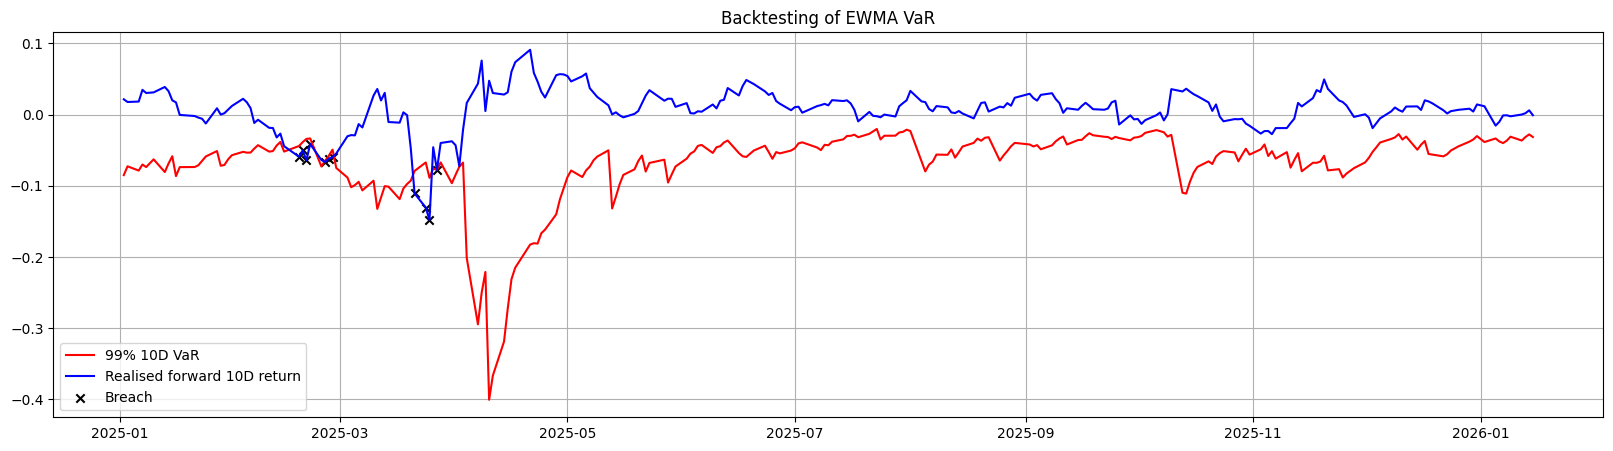

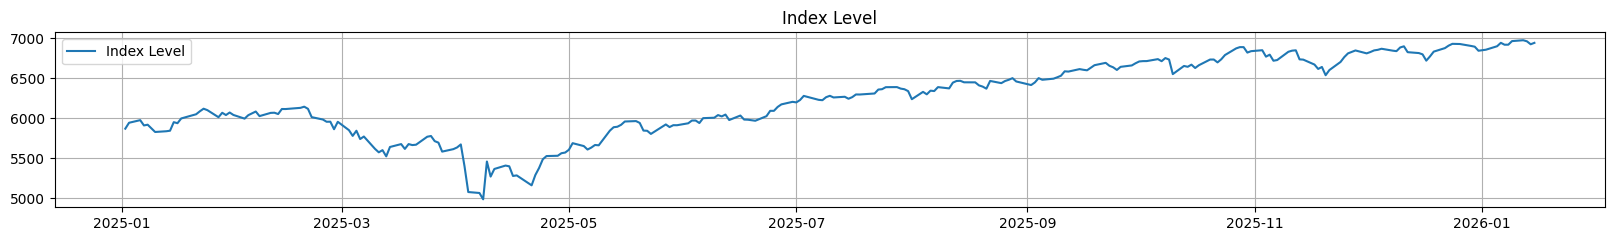

In [14]:
plt.title('Backtesting of EWMA VaR')
fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 20
fig_size[1] = 5
plt.rcParams["figure.figsize"] = fig_size
varPlt, = plt.plot(data.index, data['VaR'], color='RED')
r10dplt, = plt.plot(data.index, data['Forward10dReturn'], color='BLUE')
varBreachPlt = plt.scatter(data_breach.index, data_breach['Forward10dReturn'], color='BLACK', marker='x')
plt.legend(["99% 10D VaR", "Realised forward 10D return", "Breach"])
plt.grid()

fig = plt.figure()
ax1 = fig.add_subplot(211)
ax1.set_title('Index Level')
ax1.plot(data.index, data['^GSPC'])
ax1.legend(["Index Level"])
ax1.grid()
plt.show()

---

## Answer 4.c

Among the three approaches, EWMA is the most adaptive because it places exponentially greater weight on recent returns and therefore responds most quickly to volatility changes.

The rolling-window method is less adaptive, since all observations inside the window receive equal weight and older information disappears only when it leaves the window.

Historical simulation is the least adaptive, because it relies on the empirical distribution of past returns and does not model volatility dynamics explicitly.